# <span style="font-width:bold; font-size: 3rem; color:#1EB182;"> **Air Quality** </span><span style="font-width:bold; font-size: 3rem; color:#333;">- Part 04: Batch Inference</span>

## 🗒️ This notebook is divided into the following sections:

1. Download model and batch inference data
2. Make predictions, generate PNG for forecast
3. Store predictions in a monitoring feature group adn generate PNG for hindcast

## <span style='color:#ff5f27'> 📝 Imports

In [1]:
import sys
from pathlib import Path

root_dir = Path().absolute()
# Strip ~/notebooks/ccfraud from PYTHON_PATH if notebook started in one of these subdirectories
if root_dir.parts[-1:] == ('notebooks',):
    root_dir = Path(*root_dir.parts[:-1])
    sys.path.append(str(root_dir))
if root_dir.parts[-1:] == ('airquality',):
    root_dir = Path(*root_dir.parts[:-1])
    sys.path.append(str(root_dir))
root_dir = str(root_dir) 

print(f"Root dir: {root_dir}")

# Set the environment variables from the file <root_dir>/.env
from mlfs import config
settings = config.HopsworksSettings(_env_file=f"{root_dir}/.env")

Root dir: /Users/igormedeiros/Workspaces/irgmedeiros/mlfs-book
HopsworksSettings initialized!


In [2]:
import datetime
import pandas as pd
from xgboost import XGBRegressor
import hopsworks
import json
from airquality import util

In [3]:
today = datetime.datetime.now() - datetime.timedelta(0)
tomorrow = today + datetime.timedelta(days = 1)
today

datetime.datetime(2026, 7, 7, 21, 57, 10, 632514)

## <span style="color:#ff5f27;"> 📡 Connect to Hopsworks Feature Store </span>

In [4]:
project = hopsworks.login()
fs = project.get_feature_store() 

secrets = hopsworks.get_secrets_api()
location_str = secrets.get_secret("SENSOR_LOCATION_JSON").value
location = json.loads(location_str)
country=location['country']
city=location['city']
street=location['street']

2026-07-07 21:57:10,649 INFO: Initializing external client


2026-07-07 21:57:10,649 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443


2026-07-07 21:57:11,572 INFO: Python Engine initialized.



Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/36986


## <span style="color:#ff5f27;">🪝 Download the model from Model Registry</span>

In [5]:
mr = project.get_model_registry()

retrieved_model = mr.get_model(
    name="air_quality_xgboost_model",
    version=1,
)

fv = retrieved_model.get_feature_view()

# Download the saved model artifacts to a local directory
saved_model_dir = retrieved_model.download()

2026-07-07 21:57:17,616 INFO: Initializing for batch retrieval of feature vectors


Downloading: 0.000%|          | 0/508387 elapsed<00:00 remaining<?

Downloading: 100.000%|██████████| 508387/508387 elapsed<00:00 remaining<00:00

Downloading: 100.000%|██████████| 508387/508387 elapsed<00:00 remaining<00:00

Downloading: 0.000%|          | 0/75460 elapsed<00:00 remaining<?

Downloading: 100.000%|██████████| 75460/75460 elapsed<00:00 remaining<00:00

Downloading: 0.000%|          | 0/18658 elapsed<00:00 remaining<?

Downloading: 100.000%|██████████| 18658/18658 elapsed<00:00 remaining<00:00

In [6]:
# Loading the XGBoost regressor model and label encoder from the saved model directory
# retrieved_xgboost_model = joblib.load(saved_model_dir + "/xgboost_regressor.pkl")
retrieved_xgboost_model = XGBRegressor()

retrieved_xgboost_model.load_model(saved_model_dir + "/model.json")

# Displaying the retrieved XGBoost regressor model
retrieved_xgboost_model

XGBRegressor(base_score=[24.94242], booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None,
             feature_types=['float', 'float', 'float', 'float'],
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

## <span style="color:#ff5f27;">✨ Get Weather Forecast Features with Feature View   </span>



In [7]:
weather_fg = fs.get_feature_group(
    name='weather',
    version=1,
)
batch_data = weather_fg.filter(weather_fg.date >= today).read()
batch_data

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (0.98s) 


,date,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,wind_direction_10m_dominant,city
0,2026-07-08,16.912500,0.0,19.483284,343.909119,Stockholm
1,2026-07-09,20.762501,0.0,20.548401,356.987274,Stockholm
2,2026-07-10,22.812500,0.0,15.273505,44.999897,Stockholm
3,2026-07-11,23.212500,0.3,13.339445,356.906006,Stockholm
4,2026-07-12,17.962500,0.6,16.055353,340.346100,Stockholm
5,2026-07-13,21.162500,0.0,19.799999,360.000000,Stockholm


### <span style="color:#ff5f27;">🤖 Making the predictions</span>

In [8]:
batch_data['predicted_pm25'] = retrieved_xgboost_model.predict(
    batch_data[['temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_max', 'wind_direction_10m_dominant']])
batch_data

,date,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,wind_direction_10m_dominant,city,predicted_pm25
0,2026-07-08,16.912500,0.0,19.483284,343.909119,Stockholm,13.253658
1,2026-07-09,20.762501,0.0,20.548401,356.987274,Stockholm,33.891979
2,2026-07-10,22.812500,0.0,15.273505,44.999897,Stockholm,30.096125
3,2026-07-11,23.212500,0.3,13.339445,356.906006,Stockholm,46.271011
4,2026-07-12,17.962500,0.6,16.055353,340.346100,Stockholm,25.215254
5,2026-07-13,21.162500,0.0,19.799999,360.000000,Stockholm,33.397827


In [9]:
batch_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   date                         6 non-null      datetime64[us]
 1   temperature_2m_mean          6 non-null      float32       
 2   precipitation_sum            6 non-null      float32       
 3   wind_speed_10m_max           6 non-null      float32       
 4   wind_direction_10m_dominant  6 non-null      float32       
 5   city                         6 non-null      object        
 6   predicted_pm25               6 non-null      float32       
dtypes: datetime64[us](1), float32(5), object(1)
memory usage: 348.0+ bytes


### <span style="color:#ff5f27;">🤖 Saving the predictions (for monitoring) to a Feature Group</span>

In [10]:
batch_data['street'] = street
batch_data['city'] = city
batch_data['country'] = country
# Fill in the number of days before the date on which you made the forecast (base_date)
batch_data['days_before_forecast_day'] = range(1, len(batch_data)+1)
batch_data = batch_data.sort_values(by=['date'])
batch_data

,date,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,wind_direction_10m_dominant,city,predicted_pm25,street,country,days_before_forecast_day
0,2026-07-08,16.912500,0.0,19.483284,343.909119,Stockholm,13.253658,Hornsgatan-108,Sweden,1
1,2026-07-09,20.762501,0.0,20.548401,356.987274,Stockholm,33.891979,Hornsgatan-108,Sweden,2
2,2026-07-10,22.812500,0.0,15.273505,44.999897,Stockholm,30.096125,Hornsgatan-108,Sweden,3
3,2026-07-11,23.212500,0.3,13.339445,356.906006,Stockholm,46.271011,Hornsgatan-108,Sweden,4
4,2026-07-12,17.962500,0.6,16.055353,340.346100,Stockholm,25.215254,Hornsgatan-108,Sweden,5
5,2026-07-13,21.162500,0.0,19.799999,360.000000,Stockholm,33.397827,Hornsgatan-108,Sweden,6


In [11]:
batch_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   date                         6 non-null      datetime64[us]
 1   temperature_2m_mean          6 non-null      float32       
 2   precipitation_sum            6 non-null      float32       
 3   wind_speed_10m_max           6 non-null      float32       
 4   wind_direction_10m_dominant  6 non-null      float32       
 5   city                         6 non-null      object        
 6   predicted_pm25               6 non-null      float32       
 7   street                       6 non-null      object        
 8   country                      6 non-null      object        
 9   days_before_forecast_day     6 non-null      int64         
dtypes: datetime64[us](1), float32(5), int64(1), object(3)
memory usage: 492.0+ bytes


### Create Forecast Graph
Draw a graph of the predictions with dates as a PNG and save it to the github repo
Show it on github pages

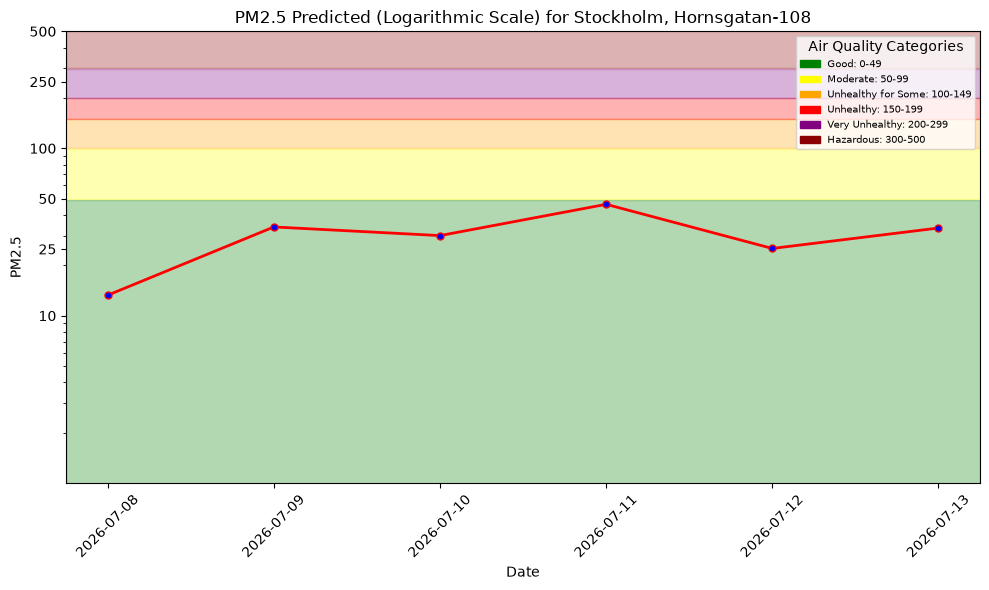

In [12]:

pred_file_path = f"{root_dir}/docs/air-quality/assets/img/pm25_forecast.png"
plt = util.plot_air_quality_forecast(city, street, batch_data, pred_file_path)

plt.show()

In [13]:
# Get or create feature group
monitor_fg = fs.get_or_create_feature_group(
    name='aq_predictions',
    description='Air Quality prediction monitoring',
    version=1,
    primary_key=['city','street','date','days_before_forecast_day'],
    event_time="date"
)

In [14]:
monitor_fg.insert(batch_data, wait=True)

Feature Group created successfully, explore it at 
https://eu-west.cloud.hopsworks.ai:443/p/36986/fs/26695/fg/47136


2026-07-07 21:57:41,289 INFO: Computing insert statistics


(None, None)

In [15]:
# We will create a hindcast chart for  only the forecasts made 1 day beforehand
monitoring_df = monitor_fg.filter(monitor_fg.days_before_forecast_day == 1).read()
monitoring_df

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (0.87s) 


,date,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,wind_direction_10m_dominant,city,predicted_pm25,street,country,days_before_forecast_day
0,2026-07-08,16.9125,0.0,19.483284,343.909119,Stockholm,13.253658,Hornsgatan-108,Sweden,1


In [16]:
air_quality_fg = fs.get_feature_group(name='air_quality', version=1)
air_quality_df = air_quality_fg.read()
air_quality_df

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (1.22s) 


,date,pm25,country,city,street,url
0,2026-07-07,8.0,Sweden,Stockholm,Hornsgatan-108,https://api.waqi.info/feed/@10009
1,2025-07-01,14.0,Sweden,Stockholm,Hornsgatan-108,https://api.waqi.info/feed/@10009
2,2025-07-02,27.0,Sweden,Stockholm,Hornsgatan-108,https://api.waqi.info/feed/@10009
3,2025-07-03,22.0,Sweden,Stockholm,Hornsgatan-108,https://api.waqi.info/feed/@10009
4,2025-07-04,9.0,Sweden,Stockholm,Hornsgatan-108,https://api.waqi.info/feed/@10009
...,...,...,...,...,...,...
2770,2017-12-26,16.0,Sweden,Stockholm,Hornsgatan-108,https://api.waqi.info/feed/@10009
2771,2017-12-27,10.0,Sweden,Stockholm,Hornsgatan-108,https://api.waqi.info/feed/@10009
2772,2017-12-28,55.0,Sweden,Stockholm,Hornsgatan-108,https://api.waqi.info/feed/@10009
2773,2017-12-29,42.0,Sweden,Stockholm,Hornsgatan-108,https://api.waqi.info/feed/@10009


In [17]:
outcome_df = air_quality_df[['date', 'pm25']]
preds_df =  monitoring_df[['date', 'predicted_pm25']]

hindcast_df = pd.merge(preds_df, outcome_df, on="date")
hindcast_df = hindcast_df.sort_values(by=['date'])

# If there are no outcomes for predictions yet, generate some predictions/outcomes from existing data
if len(hindcast_df) == 0:
    hindcast_df = util.backfill_predictions_for_monitoring(weather_fg, air_quality_df, monitor_fg, retrieved_xgboost_model)
hindcast_df

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (1.02s) 


2026-07-07 21:58:29,930 INFO: Computing insert statistics


,date,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,wind_direction_10m_dominant,city,predicted_pm25,pm25,street,country,days_before_forecast_day
0,2026-07-07,15.762501,0.1,10.464798,183.945114,Stockholm,22.308966,8.0,Hornsgatan-108,Sweden,1


### Plot the Hindcast comparing predicted with forecasted values (1-day prior forecast)

__This graph will be empty to begin with - this is normal.__

After a few days of predictions and observations, you will get data points in this graph.

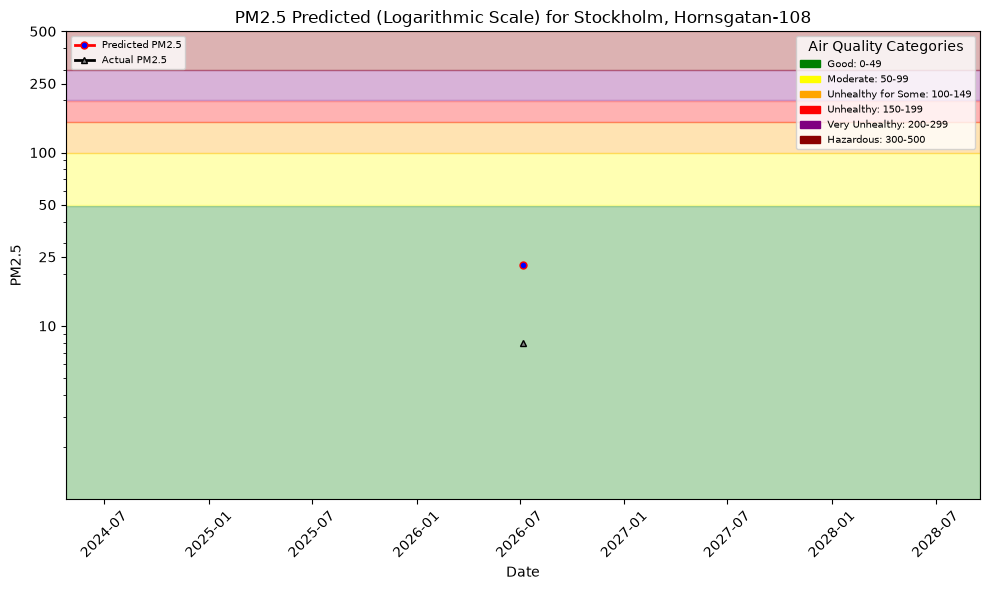

In [18]:
hindcast_file_path = f"{root_dir}/docs/air-quality/assets/img/pm25_hindcast_1day.png"
plt = util.plot_air_quality_forecast(city, street, hindcast_df, hindcast_file_path, hindcast=True)
plt.show()

### Upload the prediction and hindcast dashboards (png files) to Hopsworks


In [19]:
dataset_api = project.get_dataset_api()
str_today = today.strftime("%Y-%m-%d")
if dataset_api.exists("Resources/airquality") == False:
    dataset_api.mkdir("Resources/airquality")
dataset_api.upload(pred_file_path, f"Resources/airquality/{city}_{street}_{str_today}", overwrite=True)
dataset_api.upload(hindcast_file_path, f"Resources/airquality/{city}_{street}_{str_today}", overwrite=True)

proj_url = project.get_url()
print(f"See images in Hopsworks here: {proj_url}/settings/fb/path/Resources/airquality")

Uploading /Users/igormedeiros/Workspaces/irgmedeiros/mlfs-book/docs/air-quality/assets/img/pm25_forecast.png: 0.000%|          | 0/46228 elapsed<00:00 remaining<?

Uploading /Users/igormedeiros/Workspaces/irgmedeiros/mlfs-book/docs/air-quality/assets/img/pm25_forecast.png: 100.000%|██████████| 46228/46228 elapsed<00:01 remaining<00:00

Uploading /Users/igormedeiros/Workspaces/irgmedeiros/mlfs-book/docs/air-quality/assets/img/pm25_forecast.png: 100.000%|██████████| 46228/46228 elapsed<00:01 remaining<00:00

Uploading /Users/igormedeiros/Workspaces/irgmedeiros/mlfs-book/docs/air-quality/assets/img/pm25_hindcast_1day.png: 0.000%|          | 0/41086 elapsed<00:00 remaining<?

Uploading /Users/igormedeiros/Workspaces/irgmedeiros/mlfs-book/docs/air-quality/assets/img/pm25_hindcast_1day.png: 100.000%|██████████| 41086/41086 elapsed<00:00 remaining<00:00

Uploading /Users/igormedeiros/Workspaces/irgmedeiros/mlfs-book/docs/air-quality/assets/img/pm25_hindcast_1day.png: 100.000%|██████████| 41086/41086 elapsed<00:00 remaining<00:00

See images in Hopsworks here: https://eu-west.cloud.hopsworks.ai:443/p/36986/settings/fb/path/Resources/airquality


### Upload training hindcast from model artifacts to Resources

In [20]:
import os

training_hindcast_path = os.path.join(saved_model_dir, "images", "pm25_hindcast.png")
if os.path.exists(training_hindcast_path):
    dataset_api.upload(training_hindcast_path, "Resources/airquality", overwrite=True)
    print(f"Uploaded training hindcast to Resources/airquality/pm25_hindcast.png")
else:
    print(f"Warning: Training hindcast not found at {training_hindcast_path}")

Uploading /tmp/hopsworks/models/featurestorebook/air_quality_xgboost_model/1/air_quality_xgboost_model_1/images/pm25_hindcast.png: 0.000%|          | 0/75460 elapsed<00:00 remaining<?

Uploading /tmp/hopsworks/models/featurestorebook/air_quality_xgboost_model/1/air_quality_xgboost_model_1/images/pm25_hindcast.png: 100.000%|██████████| 75460/75460 elapsed<00:00 remaining<00:00

Uploading /tmp/hopsworks/models/featurestorebook/air_quality_xgboost_model/1/air_quality_xgboost_model_1/images/pm25_hindcast.png: 100.000%|██████████| 75460/75460 elapsed<00:00 remaining<00:00

Uploaded training hindcast to Resources/airquality/pm25_hindcast.png


### Create a Superset dashboard from the feature groups (via Trino)

Builds forecast, hindcast, and history charts directly from the offline feature groups using the Hopsworks Superset Python SDK (`project.get_superset_api()`).

In [21]:
# Build a Superset dashboard from the feature groups (via Trino) using the
# Hopsworks Python SDK. Feature groups are queried in Superset through the Trino
# database connection as virtual datasets:
#   delta.<project>_featurestore.<feature_group>_<version>
import json as json_mod

api = project.get_superset_api()
proj_url = project.get_url()
schema = f"{project.name.lower()}_featurestore"

DASHBOARD_TITLE = "Air Quality Dashboard"


def _list_all(resource):
    items, page = [], 0
    while True:
        j = api._request("GET", f"/api/v1/{resource}/?q=(page:{page},page_size:100)")
        batch = j.get("result", [])
        items.extend(batch)
        if len(batch) < 100:
            break
        page += 1
    return items


def _find_trino_db_id():
    for db in api.list_databases()["result"]:
        name = db.get("database_name", "") or ""
        if db.get("backend") == "trino" or "trino" in name.lower():
            return db["id"]
    raise RuntimeError(
        "No Trino database connection found in Superset. A Trino connection is "
        "required to read feature groups from Superset."
    )


def _ensure_dataset(database_id, name, sql):
    for ds in _list_all("dataset"):
        if ds.get("table_name") == name and ds.get("schema") == schema:
            return ds["id"]
    return api.create_dataset(
        database_id=database_id, table_name=name, schema=schema, sql=sql,
    )["id"]


def _replace_chart(slice_name, viz_type, datasource_id, params):
    for ch in _list_all("chart"):
        if ch.get("slice_name") == slice_name:
            api.delete_chart(ch["id"])
    return api.create_chart(
        slice_name=slice_name, viz_type=viz_type,
        datasource_id=datasource_id, params=params,
    )["id"]


def _avg_metric(col, label):
    return {
        "expressionType": "SIMPLE",
        "column": {"column_name": col, "type": "DOUBLE"},
        "aggregate": "AVG", "label": label,
        "optionName": f"metric_{label}", "hasCustomLabel": True,
    }


def _line_params(x_axis, metrics):
    return json_mod.dumps({
        "viz_type": "echarts_timeseries_line",
        "x_axis": x_axis, "time_grain_sqla": "P1D",
        "metrics": metrics, "groupby": [], "adhoc_filters": [],
        "row_limit": 10000, "show_legend": True, "markerEnabled": True,
        "y_axis_format": "SMART_NUMBER",
    })


def _build_position_json(rows, title):
    layout = {
        "DASHBOARD_VERSION_KEY": "v2",
        "ROOT_ID": {"type": "ROOT", "id": "ROOT_ID", "children": ["GRID_ID"]},
        "GRID_ID": {"type": "GRID", "id": "GRID_ID", "children": [], "parents": ["ROOT_ID"]},
        "HEADER_ID": {"id": "HEADER_ID", "type": "HEADER", "meta": {"text": title}},
    }

    def chart_node(key, cid, slice_name, width, height):
        nid = f"CHART-{key}"
        layout[nid] = {
            "type": "CHART", "id": nid, "children": [],
            "parents": ["ROOT_ID", "GRID_ID"],
            "meta": {"width": width, "height": height,
                     "chartId": cid, "sliceName": slice_name},
        }
        return nid

    for ri, row in enumerate(rows):
        row_id = f"ROW-{ri}"
        children = [chart_node(f"{ri}-{ci}", cid, name, width, height)
                    for ci, (cid, name, width, height) in enumerate(row)]
        layout[row_id] = {
            "type": "ROW", "id": row_id, "children": children,
            "parents": ["ROOT_ID", "GRID_ID"],
            "meta": {"background": "BACKGROUND_TRANSPARENT"},
        }
        for c in children:
            layout[c]["parents"] = ["ROOT_ID", "GRID_ID", row_id]
        layout["GRID_ID"]["children"].append(row_id)
    return json_mod.dumps(layout)


def _ensure_dashboard(title, position_json, chart_ids):
    dashboard_id = next(
        (d["id"] for d in _list_all("dashboard")
         if d.get("dashboard_title") == title), None)
    if dashboard_id is None:
        dashboard_id = api.create_dashboard(
            dashboard_title=title, published=True, position_json=position_json,
        )["id"]
    else:
        api.update_dashboard(
            dashboard_id, dashboard_title=title, published=True,
            position_json=position_json)
    # Persist the chart -> dashboard relation explicitly.
    for cid in chart_ids:
        api.update_chart(cid, dashboards=[dashboard_id])
    return dashboard_id


def build_air_quality_dashboard():
    """Create/refresh the Superset dashboard from the offline feature groups."""
    trino_db_id = _find_trino_db_id()

    # Datasets: feature groups exposed via Trino virtual datasets.
    forecast_ds = _ensure_dataset(
        trino_db_id, "aq_forecast",
        f"SELECT date, predicted_pm25 FROM delta.{schema}.aq_predictions_1")

    hindcast_ds = _ensure_dataset(
        trino_db_id, "aq_hindcast",
        f"""SELECT p.date AS date, p.predicted_pm25 AS predicted_pm25, a.pm25 AS actual_pm25
FROM delta.{schema}.aq_predictions_1 p
JOIN delta.{schema}.air_quality_1 a
  ON p.date = a.date AND p.city = a.city AND p.street = a.street
WHERE p.days_before_forecast_day = 1""")

    history_ds = _ensure_dataset(
        trino_db_id, "aq_history",
        f"SELECT date, pm25 FROM delta.{schema}.air_quality_1")

    # Charts.
    c_forecast = _replace_chart(
        "PM2.5 Forecast", "echarts_timeseries_line", forecast_ds,
        _line_params("date", [_avg_metric("predicted_pm25", "predicted_pm25")]))

    c_hindcast = _replace_chart(
        "PM2.5 Hindcast (1-day)", "echarts_timeseries_line", hindcast_ds,
        _line_params("date", [_avg_metric("predicted_pm25", "predicted_pm25"),
                              _avg_metric("actual_pm25", "actual_pm25")]))

    c_history = _replace_chart(
        "PM2.5 Recent History", "echarts_timeseries_line", history_ds,
        _line_params("date", [_avg_metric("pm25", "pm25")]))

    # Dashboard.
    position_json = _build_position_json([
        [(c_forecast, "PM2.5 Forecast", 6, 50), (c_hindcast, "PM2.5 Hindcast (1-day)", 6, 50)],
        [(c_history, "PM2.5 Recent History", 12, 50)],
    ], DASHBOARD_TITLE)

    dash_id = _ensure_dashboard(DASHBOARD_TITLE, position_json,
                                [c_forecast, c_hindcast, c_history])

    print(f"Datasets: forecast={forecast_ds}, hindcast={hindcast_ds}, history={history_ds}")
    print(f"Charts: forecast={c_forecast}, hindcast={c_hindcast}, history={c_history}")
    print(f"Dashboard id: {dash_id}")
    print(f"View dashboard at: {proj_url}/hopsworks-api/superset/superset/dashboard/{dash_id}/")
    return dash_id


# Building the dashboard must not break the inference pipeline: if Superset has no
# Trino connection (or Trino auth is unavailable), warn and continue.
try:
    build_air_quality_dashboard()
except Exception as e:
    print(f"WARNING: Skipped Superset dashboard build: {e}")
    print("The dashboard reads the feature groups through Superset's Trino database "
          "connection. Ensure Superset has a working Trino connection for this project.")


HTTP code: 403, HTTP reason: Forbidden, body: b'{"errorCode":320004,"usrMsg":"No valid scope found for this invocation. Valid scope for this invocation is: [SUPERSET]","errorMsg":"No valid scope found for this invocation"}', error code: 320004, error msg: No valid scope found for this invocation, user msg: No valid scope found for this invocation. Valid scope for this invocation is: [SUPERSET]
The dashboard reads the feature groups through Superset's Trino database connection. Ensure Superset has a working Trino connection for this project.


---